# Swish Analytics Data Modeling Challenge

## Objective
Predict the probability that an NFL pass play results in a sack using play-by-play, roster, depth chart, snap count, and advanced statistics data.

## Dataset Summary
- Training Seasons: 2021-2022
- Testing Season: 2023
- Play-by-play data
- Player roster data
- Depth chart data
- Snap count data
- Advanced statistics

## Approach
1. Explore the data
2. Define target variable
3. Build baseline model
4. Engineer football-specific features
5. Train advanced models
6. Evaluate and compare performance

# Data Exploration

In [248]:
import pandas as pd

players = pd.read_csv(
    "../data/NFL-20260612T145329Z-3-001/NFL/players.csv"
)

print(players.shape)
players.head()

(20753, 32)


,status,display_name,first_name,last_name,esb_id,gsis_id,birth_date,college_name,position_group,position,...,draftround,college_conference,status_description_abbr,status_short_description,gsis_it_id,short_name,smart_id,headshot,uniform_number,suffix
0,RET,'Omar Ellison,'Omar,Ellison,ELL711319,00-0004866,1971-10-08,NaN,WR,WR,...,NaN,NaN,NaN,NaN,NaN,NaN,3200454c-4c71-1319-728e-d49d3d236f8f,NaN,NaN,NaN
1,ACT,A'Shawn Robinson,A'Shawn,Robinson,ROB367960,00-0032889,1995-03-21,Alabama,DL,DE,...,2.0,Southeastern Conference,A01,Active,43335.0,A.Robinson,3200524f-4236-7960-bf20-bc060ac0f49c,https://static.www.nfl.com/image/upload/f_auto...,94,NaN
2,DEV,A.J. Arcuri,A.J.,Arcuri,ARC716900,00-0037845,1997-08-13,Michigan State,OL,T,...,7.0,Big Ten Conference,P01,Practice Squad,54726.0,A.Arcuri,32004152-4371-6900-5185-8cdd66b2ad11,https://static.www.nfl.com/image/upload/f_auto...,61,NaN
3,RES,A.J. Bouye,Arlandus,Bouye,BOU651714,00-0030228,1991-08-16,Central Florida,DB,CB,...,NaN,American Athletic Conference,R01,R/Injured,40688.0,A.Bouye,3200424f-5565-1714-cb38-07c822111a12,https://static.www.nfl.com/image/private/f_aut...,24,NaN
4,ACT,A.J. Brown,Arthur,Brown,BRO413223,00-0035676,1997-06-30,Mississippi,WR,WR,...,2.0,Southeastern Conference,A01,Active,47834.0,A.Brown,32004252-4f41-3223-e4c5-1e30dffa87f8,https://static.www.nfl.com/image/private/f_aut...,11,NaN


In [249]:
DATA_PATH = "../data/NFL-20260612T145329Z-3-001/NFL"

In [250]:
players.columns.tolist()

['status',
 'display_name',
 'first_name',
 'last_name',
 'esb_id',
 'gsis_id',
 'birth_date',
 'college_name',
 'position_group',
 'position',
 'jersey_number',
 'height',
 'weight',
 'years_of_experience',
 'team_abbr',
 'team_seq',
 'current_team_id',
 'football_name',
 'entry_year',
 'rookie_year',
 'draft_club',
 'draft_number',
 'draftround',
 'college_conference',
 'status_description_abbr',
 'status_short_description',
 'gsis_it_id',
 'short_name',
 'smart_id',
 'headshot',
 'uniform_number',
 'suffix']

In [251]:
DATA_PATH = "../data/NFL-20260612T145329Z-3-001/NFL"

pbp_2021 = pd.read_csv(f"{DATA_PATH}/play_by_play_2021.csv")
pbp_2022 = pd.read_csv(f"{DATA_PATH}/play_by_play_2022.csv")
pbp_2023 = pd.read_csv(f"{DATA_PATH}/play_by_play_2023.csv")

pbp = pd.concat(
    [pbp_2021, pbp_2022, pbp_2023],
    ignore_index=True
)

print(pbp.shape)

C:\Users\efriedman\AppData\Local\Temp\ipykernel_36000\1200466979.py:3: DtypeWarning: Columns (0: lateral_receiver_player_id, 1: lateral_receiver_player_name, 2: lateral_rusher_player_id, 3: lateral_rusher_player_name, 4: lateral_interception_player_id, 5: lateral_interception_player_name, 6: lateral_punt_returner_player_id, 7: lateral_punt_returner_player_name, 8: lateral_kickoff_returner_player_id, 9: lateral_kickoff_returner_player_name, 10: own_kickoff_recovery_player_id, 11: own_kickoff_recovery_player_name, 12: blocked_player_id, 13: blocked_player_name, 14: forced_fumble_player_2_team, 15: forced_fumble_player_2_player_id, 16: forced_fumble_player_2_player_name, 17: assist_tackle_3_player_id, 18: assist_tackle_3_player_name, 19: assist_tackle_3_team, 20: assist_tackle_4_player_id, 21: assist_tackle_4_player_name, 22: assist_tackle_4_team, 23: fumbled_2_player_id, 24: fumbled_2_player_name, 25: fumbled_2_team, 26: fumble_recovery_2_team, 27: fumble_recovery_2_player_id, 28: fumble

(149021, 372)


In [252]:
for col in pbp.columns:
    print(col)

play_id
game_id
old_game_id
home_team
away_team
season_type
week
posteam
posteam_type
defteam
side_of_field
yardline_100
game_date
quarter_seconds_remaining
half_seconds_remaining
game_seconds_remaining
game_half
quarter_end
drive
sp
qtr
down
goal_to_go
time
yrdln
ydstogo
ydsnet
desc
play_type
yards_gained
shotgun
no_huddle
qb_dropback
qb_kneel
qb_spike
qb_scramble
pass_length
pass_location
air_yards
yards_after_catch
run_location
run_gap
field_goal_result
kick_distance
extra_point_result
two_point_conv_result
home_timeouts_remaining
away_timeouts_remaining
timeout
timeout_team
td_team
td_player_name
td_player_id
posteam_timeouts_remaining
defteam_timeouts_remaining
total_home_score
total_away_score
posteam_score
defteam_score
score_differential
posteam_score_post
defteam_score_post
score_differential_post
no_score_prob
opp_fg_prob
opp_safety_prob
opp_td_prob
fg_prob
safety_prob
td_prob
extra_point_prob
two_point_conversion_prob
ep
epa
total_home_epa
total_away_epa
total_home_rush_epa


In [253]:
[col for col in pbp.columns if "sack" in col.lower()]

['sack',
 'lateral_sack_player_id',
 'lateral_sack_player_name',
 'sack_player_id',
 'sack_player_name',
 'half_sack_1_player_id',
 'half_sack_1_player_name',
 'half_sack_2_player_id',
 'half_sack_2_player_name']

In [254]:
[col for col in pbp.columns if "pass" in col.lower()]

['pass_length',
 'pass_location',
 'total_home_pass_epa',
 'total_away_pass_epa',
 'total_home_pass_wpa',
 'total_away_pass_wpa',
 'first_down_pass',
 'incomplete_pass',
 'pass_attempt',
 'pass_touchdown',
 'complete_pass',
 'passer_player_id',
 'passer_player_name',
 'passing_yards',
 'pass_defense_1_player_id',
 'pass_defense_1_player_name',
 'pass_defense_2_player_id',
 'pass_defense_2_player_name',
 'passer',
 'passer_jersey_number',
 'pass',
 'passer_id',
 'xpass',
 'pass_oe']

In [255]:
pbp[["pass", "xpass", "pass_oe"]].head(10)

,pass,xpass,pass_oe
0,0,NaN,NaN
1,0,NaN,NaN
2,0,0.491433,-49.143299
3,1,0.697346,30.265415
4,1,0.978253,2.174652
5,0,NaN,NaN
6,1,0.458989,54.101130
7,0,0.419833,-41.983327
8,1,0.684949,31.505138
9,1,0.775463,22.453719


In [256]:
model_df = pbp[pbp["pass"] == 1].copy()

print(model_df.shape)

model_df[["sack"]].value_counts(normalize=True)

(68610, 372)


sack
0.0     0.939726
1.0     0.060274
Name: proportion, dtype: float64

In [257]:
model_df[[
    "sack",
    "down",
    "ydstogo",
    "yardline_100",
    "qtr",
    "game_seconds_remaining",
    "week",
    "xpass",
    "pass_oe"
]].head()

,sack,down,ydstogo,yardline_100,qtr,game_seconds_remaining,week,xpass,pass_oe
3,0.0,2.0,13,78.0,1,3563.0,1,0.697346,30.265415
4,0.0,3.0,10,75.0,1,3522.0,1,0.978253,2.174652
6,0.0,1.0,10,61.0,1,3507.0,1,0.458989,54.101130
8,0.0,1.0,18,31.0,1,3446.0,1,0.684949,31.505138
9,0.0,2.0,17,30.0,1,3414.0,1,0.775463,22.453719


In [258]:
model_df[[
    "sack",
    "down",
    "ydstogo",
    "yardline_100",
    "qtr",
    "game_seconds_remaining",
    "week",
    "xpass",
    "pass_oe"
]].isnull().sum()

sack                       90
down                      320
ydstogo                     0
yardline_100                0
qtr                         0
game_seconds_remaining      0
week                        0
xpass                     320
pass_oe                   320
dtype: int64

## 3. Data Cleaning

Before modeling, we examine missing values and remove observations with incomplete target or feature data.

Features selected for the baseline model:

- Down
- Yards to Go
- Yardline
- Quarter
- Game Seconds Remaining
- Week
- Expected Completion Percentage (xPass)
- Pass Offensive Efficiency (Pass OE)

Target:

- Sack (1 = sack, 0 = no sack)

In [259]:
features = [
    "down",
    "ydstogo",
    "yardline_100",
    "qtr",
    "game_seconds_remaining",
    "week",
    "xpass",
    "pass_oe"
]

model_df = model_df.dropna(subset=["sack"] + features)

print(model_df.shape)

(68202, 372)


## 4. Baseline Model Dataset

Create feature matrix (X) and target vector (y).

In [260]:
X = model_df[features]

y = model_df["sack"]

print(X.shape)
print(y.shape)

(68202, 8)
(68202,)


## 5. Train/Test Split

Split the data into training and testing sets to evaluate out-of-sample performance.

In [261]:
from sklearn.model_selection import train_test_split

train_df = model_df[model_df["season"] < 2023]
test_df = model_df[model_df["season"] == 2023]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (45338, 372)
Test shape: (22864, 372)


In [262]:
X_train = train_df[features]
X_test = test_df[features]

y_train = train_df["sack"]
y_test = test_df["sack"]

print(X_train.shape)
print(X_test.shape)

(45338, 8)
(22864, 8)


## 6. Baseline Logistic Regression

Train a simple logistic regression model using only game state variables.

In [263]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [264]:
from sklearn.metrics import roc_auc_score

pred_probs = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, pred_probs)

print(f"AUC: {auc:.3f}")

AUC: 0.584


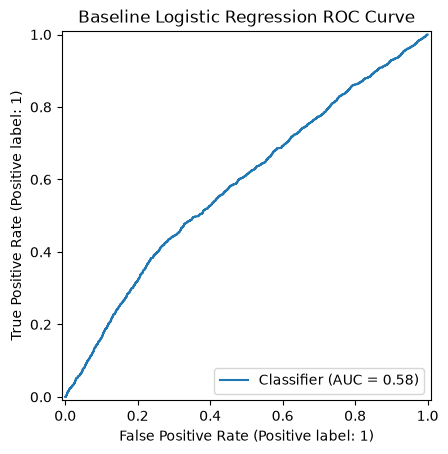

In [265]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, pred_probs)

plt.title("Baseline Logistic Regression ROC Curve")
plt.savefig("../outputs/figures/baseline_roc_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [266]:
[col for col in pbp.columns if "pressure" in col.lower()]

[]

In [267]:
[col for col in pbp.columns if "epa" in col.lower()]

['epa',
 'total_home_epa',
 'total_away_epa',
 'total_home_rush_epa',
 'total_away_rush_epa',
 'total_home_pass_epa',
 'total_away_pass_epa',
 'air_epa',
 'yac_epa',
 'comp_air_epa',
 'comp_yac_epa',
 'total_home_comp_air_epa',
 'total_away_comp_air_epa',
 'total_home_comp_yac_epa',
 'total_away_comp_yac_epa',
 'total_home_raw_air_epa',
 'total_away_raw_air_epa',
 'total_home_raw_yac_epa',
 'total_away_raw_yac_epa',
 'qb_epa',
 'xyac_epa']

## Initial Findings

A baseline logistic regression model using only game variables achieved an ROC-AUC of 0.584.

This suggests that situational factors alone provide limited predictive power for sack prediction. Future iterations will incorporate quarterback tendencies, offensive line performance, pass rush strength, and team level historical metrics.

## 7. Feature Engineering: Team and Quarterback Context

The baseline model only used game state features. To improve predictive power, this section adds team and quarterback context, including offensive team, defensive team, and passer identity.

In [268]:
# Add categorical football context features
improved_features = features + [
    "posteam",
    "defteam",
    "passer_player_id"
]

improved_df = model_df[["sack"] + improved_features].dropna()

print(improved_df.shape)
improved_df.head()

(61841, 12)


,sack,down,ydstogo,yardline_100,qtr,game_seconds_remaining,week,xpass,pass_oe,posteam,defteam,passer_player_id
3,0.0,2.0,13,78.0,1,3563.0,1,0.697346,30.265415,TEN,ARI,00-0029701
4,0.0,3.0,10,75.0,1,3522.0,1,0.978253,2.174652,TEN,ARI,00-0029701
6,0.0,1.0,10,61.0,1,3507.0,1,0.458989,54.101130,ARI,TEN,00-0035228
8,0.0,1.0,18,31.0,1,3446.0,1,0.684949,31.505138,ARI,TEN,00-0035228
9,0.0,2.0,17,30.0,1,3414.0,1,0.775463,22.453719,ARI,TEN,00-0035228


# 8. Improved Logistic Regression

Train a logistic regression model using both game-state variables and categorical football context features.

One-hot encoding is applied to team and quarterback identifiers so the model can learn player and team specific tendencies.

In [269]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

numeric_features = features
categorical_features = ["posteam", "defteam", "passer_player_id"]

improved_features = features + categorical_features

improved_df = model_df[["sack", "season"] + improved_features].dropna()

train_df = improved_df[improved_df["season"] < 2023]
test_df = improved_df[improved_df["season"] == 2023]

X_train = train_df[improved_features]
X_test = test_df[improved_features]

y_train = train_df["sack"]
y_test = test_df["sack"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

improved_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

improved_model.fit(X_train, y_train)

improved_pred_probs = improved_model.predict_proba(X_test)[:, 1]

improved_auc = roc_auc_score(y_test, improved_pred_probs)

print(f"Improved Logistic Regression AUC: {improved_auc:.3f}")

Improved Logistic Regression AUC: 0.598


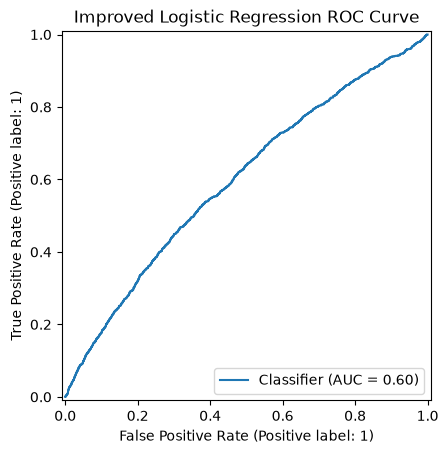

In [270]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    improved_pred_probs
)

plt.title("Improved Logistic Regression ROC Curve")
plt.savefig("../outputs/figures/improved_roc_curve.png",
            bbox_inches="tight")
plt.show()

# 9. Historical Sack Tendencies

Quarterbacks, offenses, and defenses have persistent tendencies related to sacks.

This section calculates historical sack rates using only training-season data (2021-2022) to avoid data leakage.

In [271]:
# Create historical rates using only training seasons
historical_df = model_df[model_df["season"] < 2023].copy()

league_sack_rate = historical_df["sack"].mean()

qb_sack_rates = (
    historical_df.groupby("passer_player_name")["sack"]
    .mean()
    .reset_index()
    .rename(columns={"sack": "qb_sack_rate"})
)

offense_sack_rates = (
    historical_df.groupby("posteam")["sack"]
    .mean()
    .reset_index()
    .rename(columns={"sack": "offense_sack_rate"})
)

defense_sack_rates = (
    historical_df.groupby("defteam")["sack"]
    .mean()
    .reset_index()
    .rename(columns={"sack": "defense_sack_rate"})
)

model_df = model_df.drop(
    columns=[
        "qb_sack_rate", "offense_sack_rate", "defense_sack_rate",
        "qb_sack_rate_x", "qb_sack_rate_y",
        "offense_sack_rate_x", "offense_sack_rate_y",
        "defense_sack_rate_x", "defense_sack_rate_y"
    ],
    errors="ignore"
)

model_df = model_df.merge(qb_sack_rates, on="passer_player_name", how="left")
model_df = model_df.merge(offense_sack_rates, on="posteam", how="left")
model_df = model_df.merge(defense_sack_rates, on="defteam", how="left")

model_df["qb_sack_rate"] = model_df["qb_sack_rate"].fillna(league_sack_rate)
model_df["offense_sack_rate"] = model_df["offense_sack_rate"].fillna(league_sack_rate)
model_df["defense_sack_rate"] = model_df["defense_sack_rate"].fillna(league_sack_rate)

model_df[[
    "qb_sack_rate",
    "offense_sack_rate",
    "defense_sack_rate"
]].isnull().sum()

qb_sack_rate         0
offense_sack_rate    0
defense_sack_rate    0
dtype: int64

# 10. Historical Sack Rate Model

Incorporate historical quarterback, offensive, and defensive sack rates into the feature set and evaluate their predictive value.

These features provide a direct measure of past sack performance beyond game-state information alone.

In [272]:
features_v3 = features + [
    "qb_sack_rate",
    "offense_sack_rate",
    "defense_sack_rate"
]

train_df = model_df[model_df["season"] < 2023]
test_df = model_df[model_df["season"] == 2023]

X_train = train_df[features_v3]
X_test = test_df[features_v3]

y_train = train_df["sack"]
y_test = test_df["sack"]

model_v3 = LogisticRegression(max_iter=1000)

model_v3.fit(X_train, y_train)

pred_probs_v3 = model_v3.predict_proba(X_test)[:, 1]

auc_v3 = roc_auc_score(y_test, pred_probs_v3)

print(f"Historical Sack Rate Model AUC: {auc_v3:.3f}")

Historical Sack Rate Model AUC: 0.606


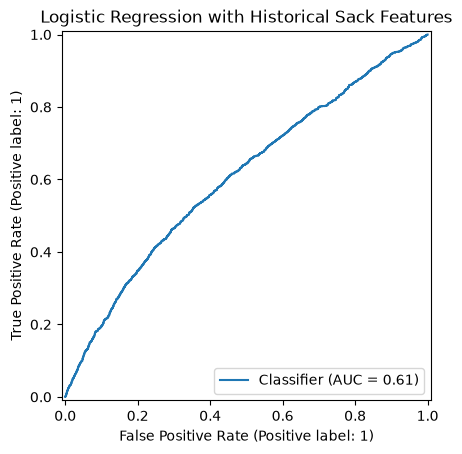

In [273]:
RocCurveDisplay.from_predictions(
    y_test,
    pred_probs_v3
)

plt.title("Logistic Regression with Historical Sack Features")
plt.savefig(
    "../outputs/figures/historical_features_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 11. Model Comparison

Compare the predictive performance of each modeling approach to determine which features provide the greatest improvement in sack prediction.

In [276]:
results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Team + QB Features",
        "Historical Sack Rates"
    ],
    "ROC_AUC": [
        auc,
        improved_auc,
        auc_v3
    ]
})

results = results.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

results

,Model,ROC_AUC
0,Historical Sack Rates,0.605775
1,Team + QB Features,0.597577
2,Baseline Logistic Regression,0.584396
